In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
train_dir = r"E:\Project\Pneumonia Classification using CNN\dataset\chest_xray\train"

test_dir = r"E:\Project\Pneumonia Classification using CNN\dataset\chest_xray\test"

val_dir = r"E:\Project\Pneumonia Classification using CNN\dataset\chest_xray\val"

In [18]:
print(os.path.exists(train_dir))
print(os.path.exists(test_dir))
print(os.path.exists(val_dir))

True
True
True


In [19]:
classes = os.listdir(train_dir)

print("Classes:", classes)

Classes: ['NORMAL', 'PNEUMONIA']


In [20]:
normal_count = len([
    f for f in os.listdir(os.path.join(train_dir, "NORMAL"))
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
])

pneumonia_count = len([
    f for f in os.listdir(os.path.join(train_dir, "PNEUMONIA"))
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
])

print("NORMAL Images:", normal_count)
print("PNEUMONIA Images:", pneumonia_count)

NORMAL Images: 1341
PNEUMONIA Images: 3875


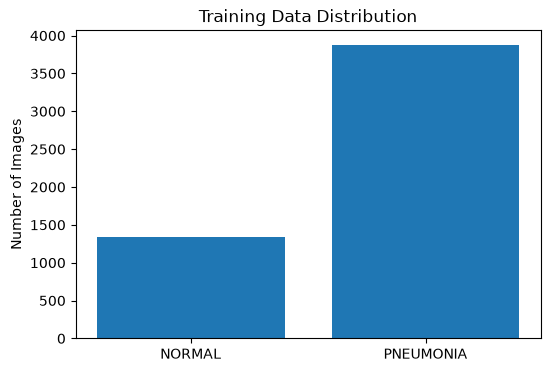

In [21]:
plt.figure(figsize=(6,4))

plt.bar(
    ["NORMAL", "PNEUMONIA"],
    [normal_count, pneumonia_count]
)

plt.title("Training Data Distribution")
plt.ylabel("Number of Images")

plt.show()

In [22]:
from PIL import Image

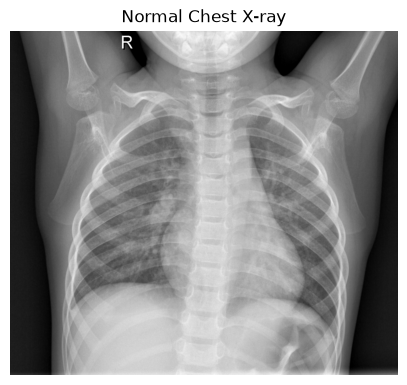

In [23]:
from PIL import Image

normal_folder = os.path.join(train_dir, "NORMAL")

image_files = [
    f for f in os.listdir(normal_folder)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

normal_image = os.path.join(normal_folder, image_files[0])

img = Image.open(normal_image)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title("Normal Chest X-ray")
plt.axis("off")
plt.show()

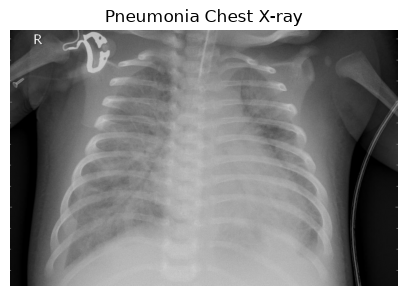

In [24]:
pneumonia_folder = os.path.join(train_dir, "PNEUMONIA")

image_files = [
    f for f in os.listdir(pneumonia_folder)
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

pneumonia_image = os.path.join(
    pneumonia_folder,
    image_files[0]
)

img = Image.open(pneumonia_image)

plt.figure(figsize=(5,5))
plt.imshow(img, cmap="gray")
plt.title("Pneumonia Chest X-ray")
plt.axis("off")
plt.show()

In [25]:
print("Normal Image Size:", Image.open(normal_image).size)
print("Pneumonia Image Size:", Image.open(pneumonia_image).size)

Normal Image Size: (2090, 1858)
Pneumonia Image Size: (1152, 760)


In [26]:
widths = []
heights = []

for category in ["NORMAL", "PNEUMONIA"]:

    folder = os.path.join(train_dir, category)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpeg", ".jpg", ".png"))
    ]

    for file in image_files[:100]:

        img = Image.open(os.path.join(folder, file))

        widths.append(img.size[0])
        heights.append(img.size[1])

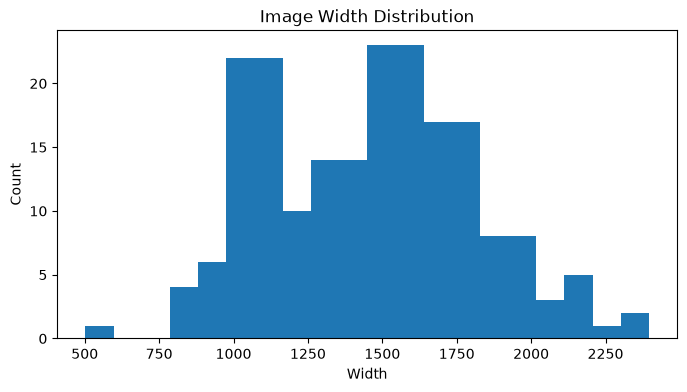

In [27]:
plt.figure(figsize=(8,4))

plt.hist(widths, bins=20)

plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")

plt.show()

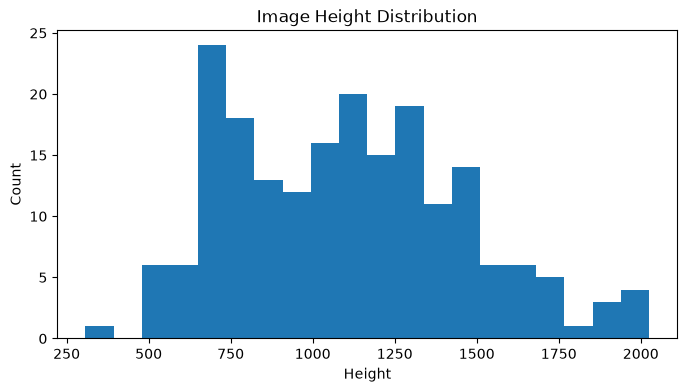

In [28]:
plt.figure(figsize=(8,4))

plt.hist(heights, bins=20)

plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")

plt.show()

# EDA Summary

- Dataset contains two classes:
  - NORMAL
  - PNEUMONIA

- Dataset is imbalanced.

- Images have different dimensions.

- Images are grayscale chest X-rays.

- Images must be resized before CNN training.

In [29]:
print(f"Total Images: {normal_count + pneumonia_count}")
print(f"NORMAL: {normal_count}")
print(f"PNEUMONIA: {pneumonia_count}")

Total Images: 5216
NORMAL: 1341
PNEUMONIA: 3875
